<a href="https://colab.research.google.com/github/YamenObeidat/Activity-3--DBSCAN-PCA/blob/main/final_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EDA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('credit_card_fraud_10k.csv')
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
df_cleaned = df.drop(columns=['transaction_id'])

le = LabelEncoder()
df_cleaned['merchant_category'] = le.fit_transform(df_cleaned['merchant_category'])

df_cleaned.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,1,0,0,66,3,40,0
1,541.82,3,4,1,0,87,1,64,0
2,237.01,17,3,0,0,49,1,61,0
3,164.33,4,3,0,1,72,3,34,0
4,30.53,15,2,0,0,79,0,44,0


In [4]:
X = df_cleaned.drop(columns=['is_fraud'])
y = df_cleaned['is_fraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_preprocessed = pd.DataFrame(X_scaled, columns=X.columns)
X_preprocessed.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,-0.521597,1.503345,-0.699651,-0.329244,-0.306158,0.195528,0.691873,-0.231580
1,2.086108,-1.241383,1.420290,3.037260,-0.306158,1.172909,-0.704299,1.370727
2,0.348151,0.781048,0.713643,-0.329244,-0.306158,-0.595686,-0.704299,1.170439
3,-0.066254,-1.096923,0.713643,-0.329244,3.266284,0.474779,0.691873,-0.632157
4,-0.829151,0.492130,0.006996,-0.329244,-0.306158,0.800573,-1.402386,0.035471


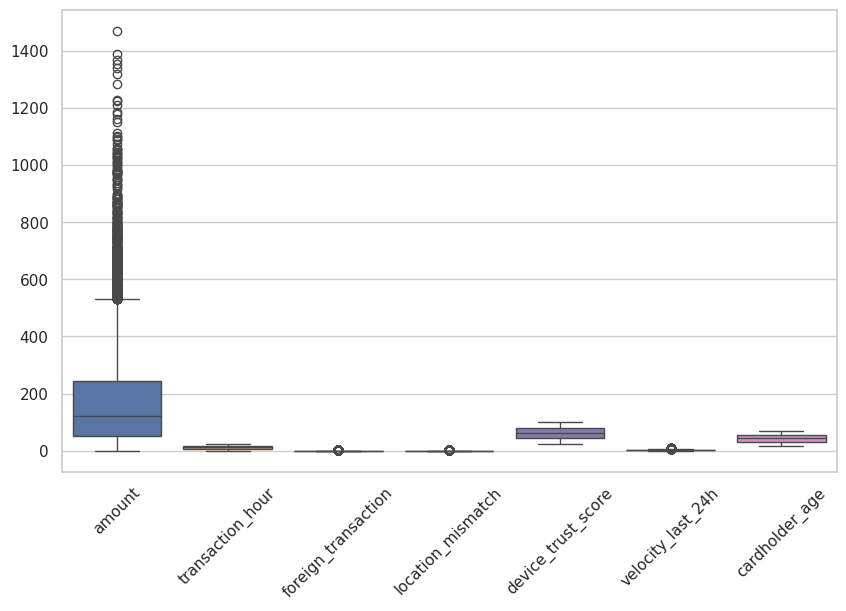

In [5]:
df.isnull().sum()
df.describe()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns=['transaction_id', 'is_fraud']))
plt.xticks(rotation=45)
plt.show()

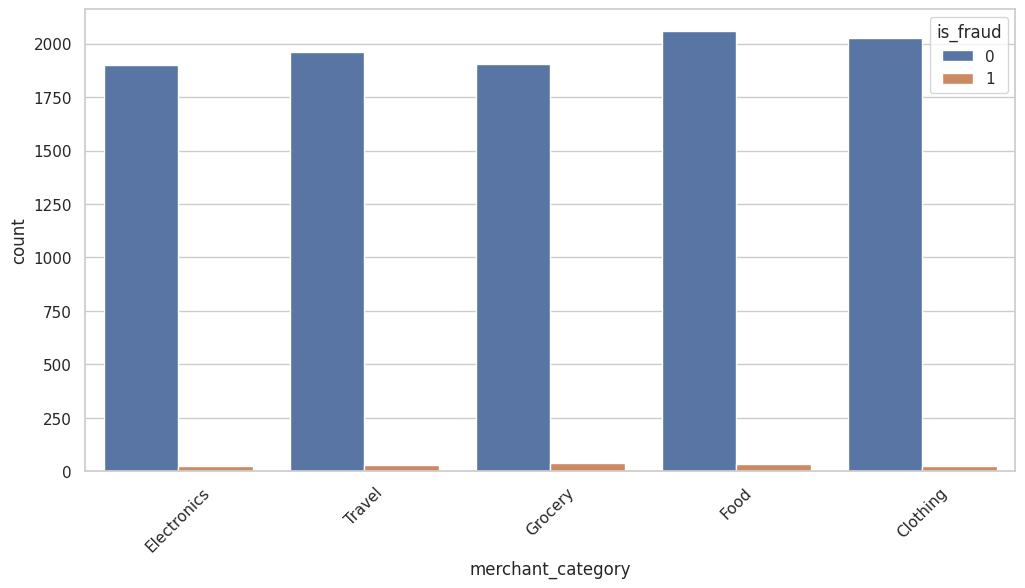

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(x='merchant_category', hue='is_fraud', data=df)
plt.xticks(rotation=45)
plt.show()

le = LabelEncoder()
df_cleaned = df.drop(columns=['transaction_id'])
df_cleaned['merchant_category'] = le.fit_transform(df_cleaned['merchant_category'])

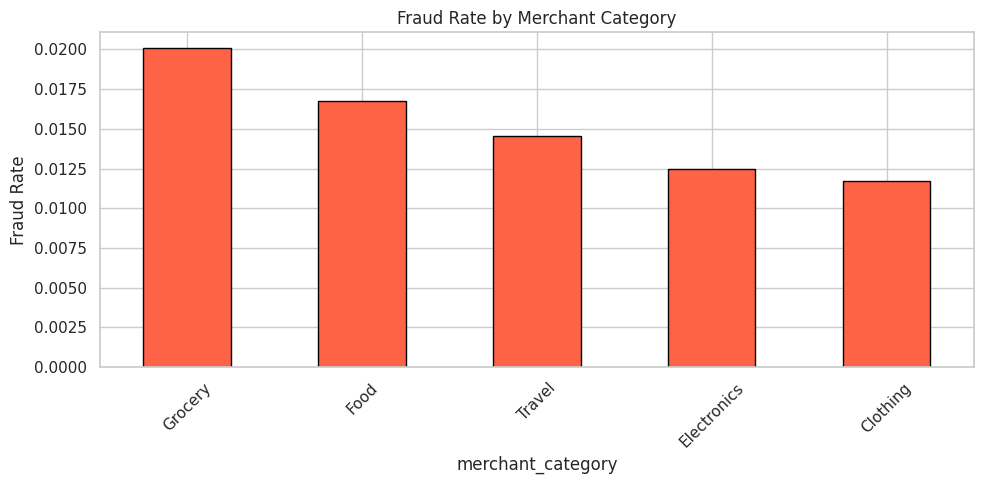

In [41]:
fraud_rate = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fraud_rate.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Fraud Rate by Merchant Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

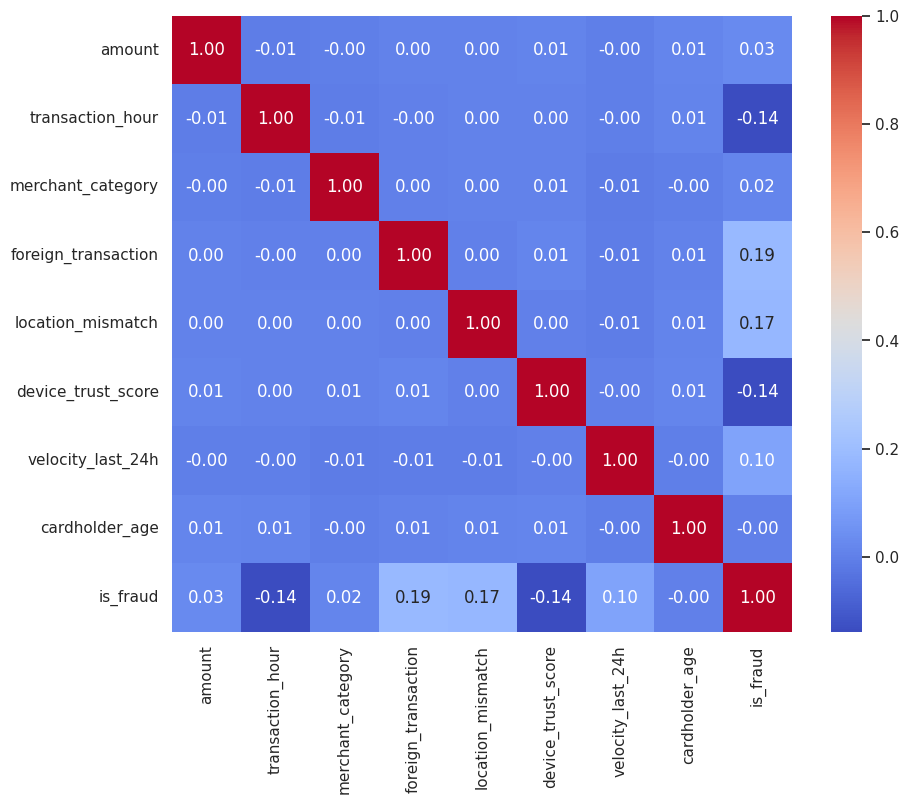

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

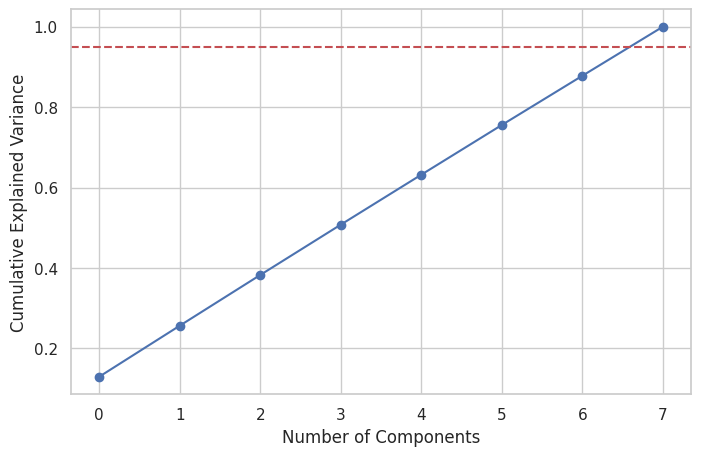

In [8]:
X = df_cleaned.drop(columns=['is_fraud'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

**PCA Components experiment**

In [9]:
pca_reduced = PCA(n_components=3)

X_pca_3 = pca_reduced.fit_transform(X_scaled)

print(X_pca_3.shape)

(10000, 3)


In [10]:
total_variance_3 = np.sum(pca_reduced.explained_variance_ratio_)
print(total_variance_3)

pca_reduced.explained_variance_ratio_

0.38262286774377463


array([0.12953643, 0.12689694, 0.1261895 ])

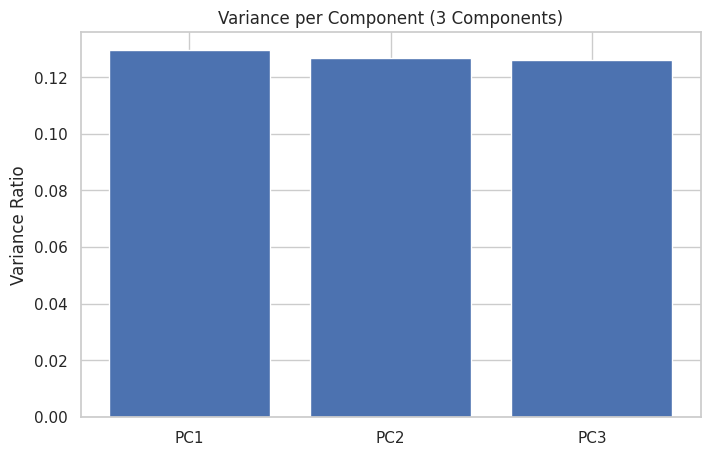

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(['PC1', 'PC2', 'PC3'], pca_reduced.explained_variance_ratio_)
plt.title('Variance per Component (3 Components)')
plt.ylabel('Variance Ratio')
plt.show()

In [12]:
pca_low = PCA(n_components=3)
X_pca_low = pca_low.fit_transform(X_scaled)
variance_retained = np.sum(pca_low.explained_variance_ratio_)
print(f"Variance Retained with 3 components: {variance_retained:.2%}")

Variance Retained with 3 components: 38.26%


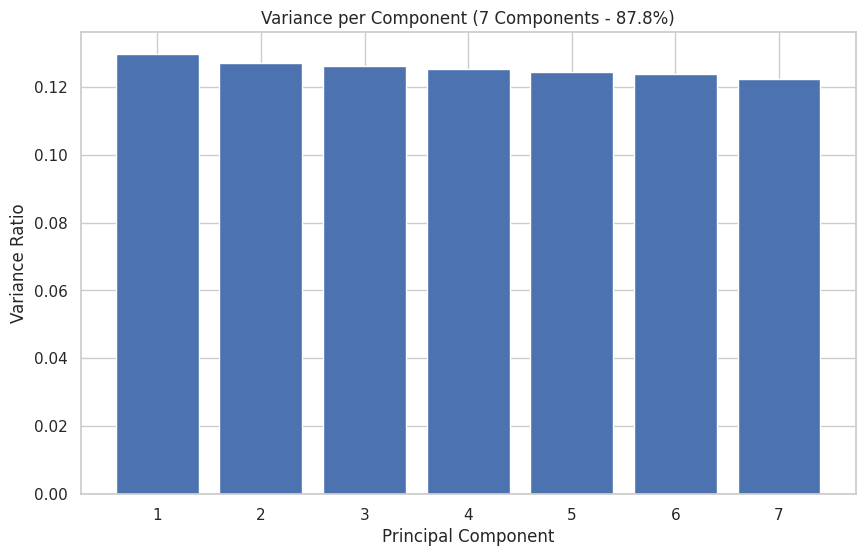

0.8780136993713322


In [13]:
pca_7 = PCA(n_components=7)
X_pca_7 = pca_7.fit_transform(X_scaled)
variance_7 = np.sum(pca_7.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, 8), pca_7.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('Variance per Component (7 Components - 87.8%)')
plt.xticks(range(1, 8))
plt.show()

print(variance_7)

In [14]:
pca_final = PCA(n_components=0.95)
X_pca = pca_final.fit_transform(X_scaled)
print(X_pca.shape)

(10000, 8)


In [15]:
pca_final = PCA(n_components=0.95)
X_pca = pca_final.fit_transform(X_scaled)
print(f"Number of components to reach 95%: {X_pca.shape[1]}")

Number of components to reach 95%: 8


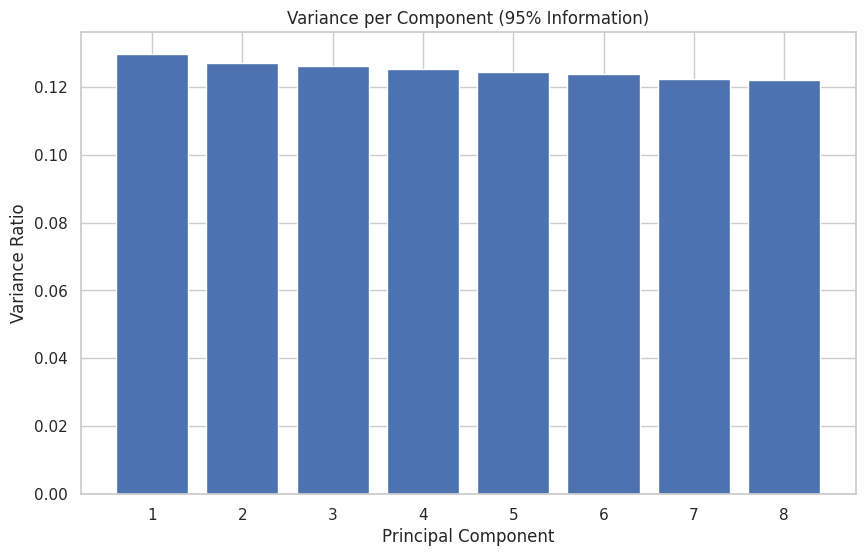

8
1.0


In [16]:
pca_final = PCA(n_components=0.95)
X_pca = pca_final.fit_transform(X_scaled)
n_comps = X_pca.shape[1]

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_comps + 1), pca_final.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('Variance per Component (95% Information)')
plt.xticks(range(1, n_comps + 1))
plt.show()

print(n_comps)
print(np.sum(pca_final.explained_variance_ratio_))

**بالبداية جربنا نستخدم 3 مكونات (components) بس، ولقينا إنها بتغطي 38.2% من البيانات، وهذا يعني إنه ضاع علينا أكثر من نص المعلومات المهمة. بعدين جربنا 7 مكونات وحسّنا النسبة لـ 87.8%، بس لسا كان ناقصنا تفاصيل ضرورية عشان الدقة. وعشان نلتزم بمتطلبات المشروع، اعتمدنا نسبة 95%، والبرنامج لحاله اختار 8 مكونات. هذا القرار النهائي بيضمن إنّا حافظنا على كل الإشارات المهمة وشلنا الـ noise اللي ماله داعي. وهيك صار عنا أساس قوي بنقدر نعتمد عليه بالخطوات الجاية للكشف عن عمليات الاحتيال.**

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


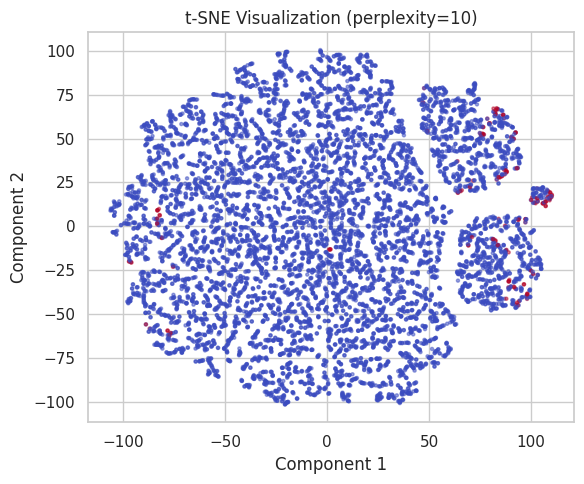

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


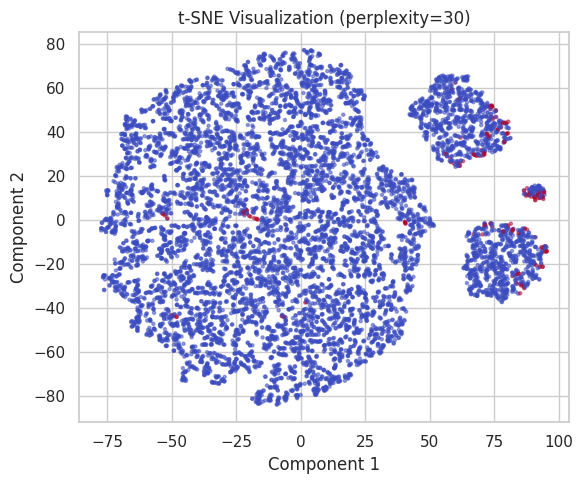

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


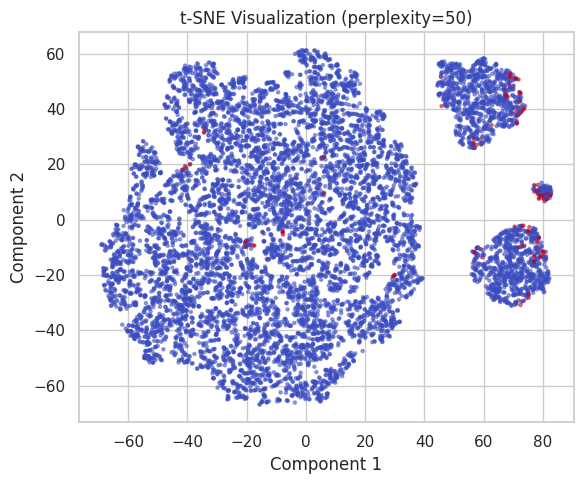

In [43]:
# Experimenting with different perplexity values
for perp in [10, 30, 50]:
    tsne_exp = TSNE(n_components=2, random_state=42, perplexity=perp, n_iter=1000)
    X_t = tsne_exp.fit_transform(X_pca)
    plt.figure(figsize=(6, 5))
    plt.scatter(X_t[:, 0], X_t[:, 1], c=y, cmap='coolwarm', alpha=0.5, s=5)
    plt.title(f't-SNE Visualization (perplexity={perp})')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


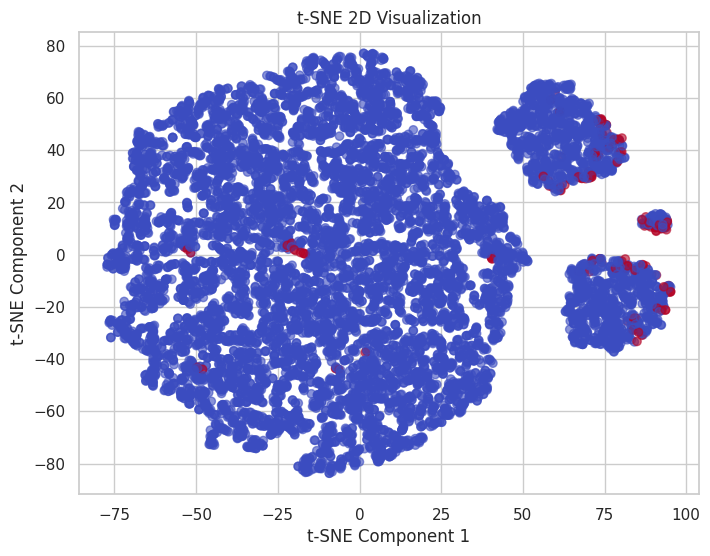

In [17]:
# Phase 3: Data Visualization with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)  # نستخدم X_pca لتسريع العملية

# رسم وتخزين الشكل البياني
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.6)
ax.set_title('t-SNE 2D Visualization')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
fig.savefig('tsne_visualization.png')

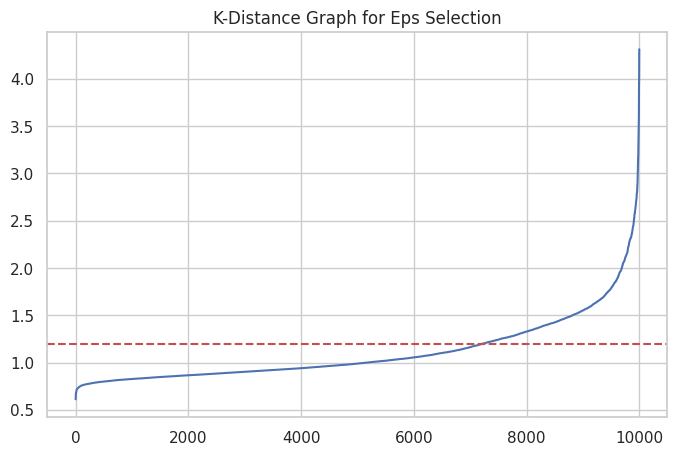

In [18]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=16)
neighbors_fit = neighbors.fit(X_pca)
distances, _ = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, 15], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph for Eps Selection')
plt.axhline(y=1.2, color='r', linestyle='--')
plt.show()

In [42]:
# Experimenting with different eps values to choose the best parameters
print(f"{'eps':<8} {'Clusters':<12} {'Noise Points':<15} {'Silhouette':}")
print("-" * 50)

for eps_val in [0.8, 1.0, 1.2, 1.5, 2.0]:
    labels = DBSCAN(eps=eps_val, min_samples=16).fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        score = silhouette_score(X_pca[mask], labels[mask])
    else:
        score = float('nan')
    print(f"{eps_val:<8} {n_clusters:<12} {n_noise:<15} {score:.3f}")

eps      Clusters     Noise Points    Silhouette
--------------------------------------------------
0.8      10           7610            -0.199
1.0      1            2982            nan
1.2      11           1576            0.208
1.5      3            375             0.311
2.0      4            106             0.305


In [19]:
dbscan = DBSCAN(eps=1.2, min_samples=16)
db_clusters = dbscan.fit_predict(X_pca)

df_cleaned['dbscan_cluster'] = db_clusters
print(df_cleaned['dbscan_cluster'].value_counts())

dbscan_cluster
 0     7864
-1     1576
 2      247
 1      178
 6       32
 8       19
 4       17
 10      16
 7       14
 3       14
 5       13
 9       10
Name: count, dtype: int64


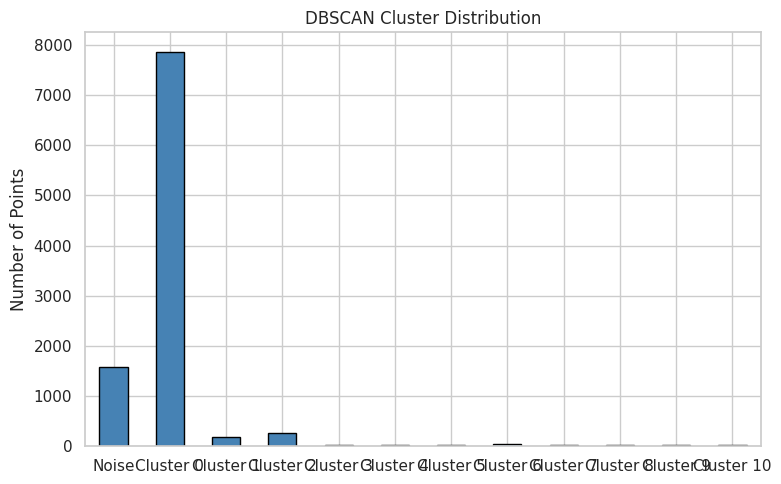

In [39]:
cluster_counts = pd.Series(db_clusters).value_counts().sort_index()
cluster_counts.index = ['Noise' if i == -1 else f'Cluster {i}' for i in cluster_counts.index]

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('DBSCAN Cluster Distribution')
plt.ylabel('Number of Points')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

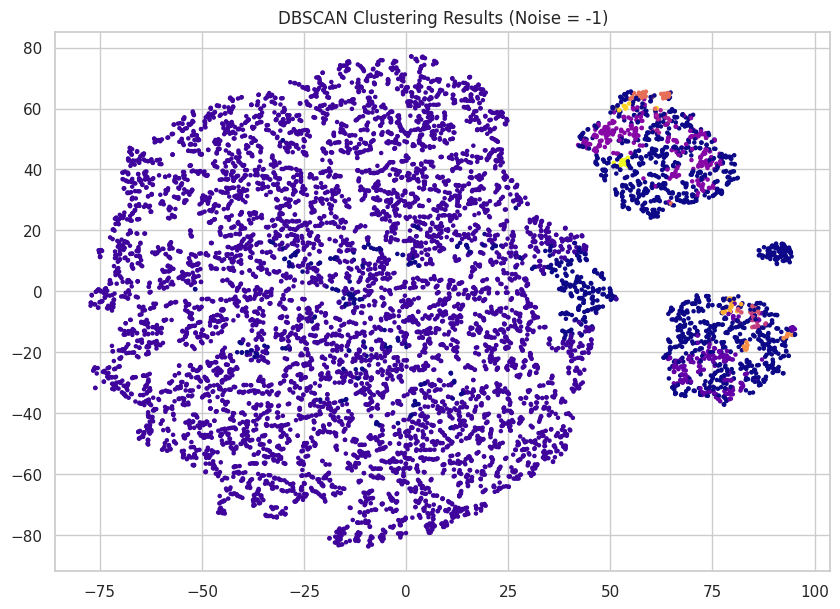

In [20]:
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=db_clusters, cmap='plasma', s=5)
plt.title('DBSCAN Clustering Results (Noise = -1)')
plt.show()

In [21]:
mask = db_clusters != -1
if len(set(db_clusters[mask])) > 1:
    s_score = silhouette_score(X_pca[mask], db_clusters[mask])
    db_index = davies_bouldin_score(X_pca[mask], db_clusters[mask])
    print(f"Silhouette Score (Excluding Noise): {s_score}")
    print(f"Davies-Bouldin Index: {db_index}")

pd.crosstab(df_cleaned['is_fraud'], df_cleaned['dbscan_cluster'])

Silhouette Score (Excluding Noise): 0.2075352386663328
Davies-Bouldin Index: 1.3579229937031707


dbscan_cluster,-1,0,1,2,3,4,5,6,7,8,9,10
is_fraud,,,,,,,,,,,,
0,1445,7853,178,240,14,17,13,32,13,18,10,16
1,131,11,0,7,0,0,0,0,1,1,0,0


ocsvm_label
 1    9498
-1     502
Name: count, dtype: int64


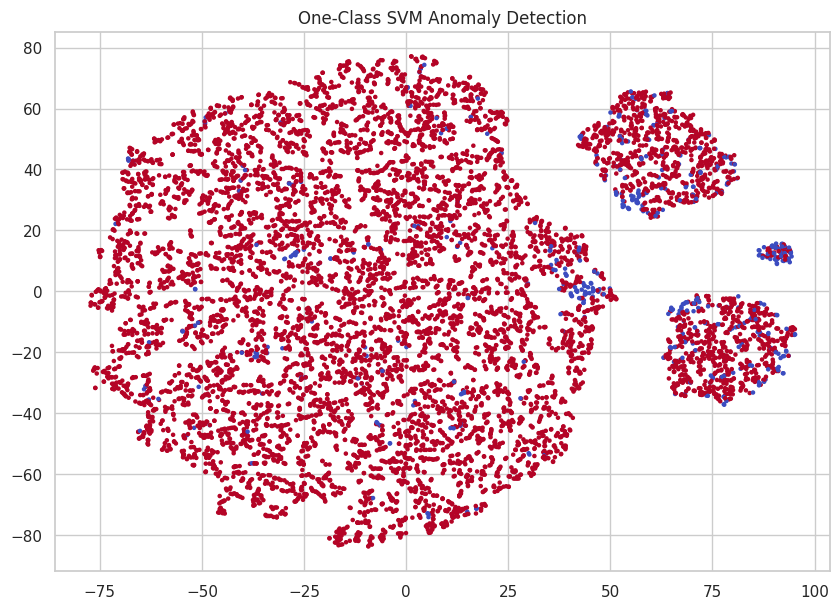

In [22]:
from sklearn.svm import OneClassSVM


ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm_outliers = ocsvm.fit_predict(X_pca)

df_cleaned['ocsvm_label'] = ocsvm_outliers
print(df_cleaned['ocsvm_label'].value_counts())

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=ocsvm_outliers, cmap='coolwarm', s=5)
plt.title('One-Class SVM Anomaly Detection')
plt.show()

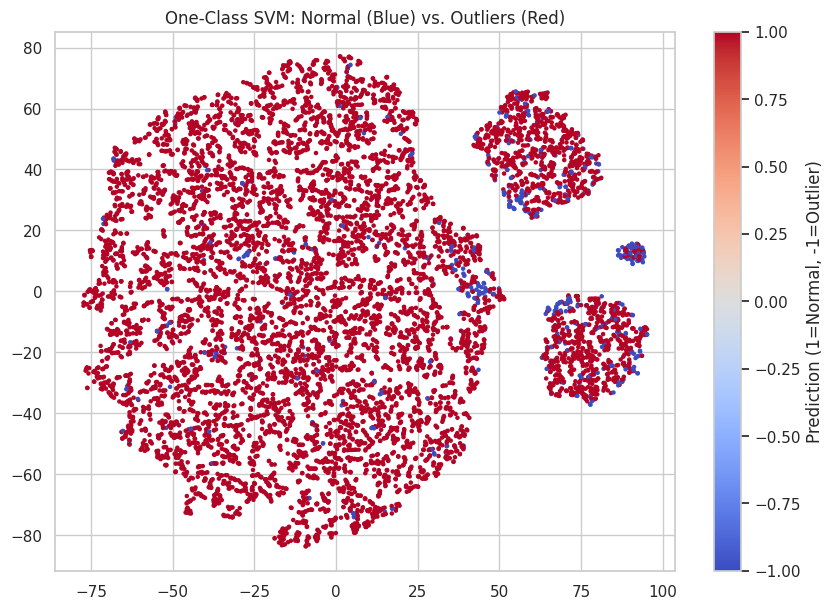

DBSCAN detected noise points: 1576
SVM detected outlier points: 506


In [23]:
from sklearn.svm import OneClassSVM

oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
oc_svm_preds = oc_svm.fit_predict(X_pca)

df_cleaned['ocsvm_cluster'] = oc_svm_preds

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=oc_svm_preds, cmap='coolwarm', s=5)
plt.title('One-Class SVM: Normal (Blue) vs. Outliers (Red)')
plt.colorbar(label='Prediction (1=Normal, -1=Outlier)')
plt.show()

print("DBSCAN detected noise points:", (db_clusters == -1).sum())
print("SVM detected outlier points:", (oc_svm_preds == -1).sum())

In [36]:
from sklearn.metrics import classification_report

ocsvm_binary = [1 if x == -1 else 0 for x in oc_svm_preds]
print("One-Class SVM Results:")
print(classification_report(df_cleaned['is_fraud'], ocsvm_binary))

One-Class SVM Results:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      9849
           1       0.16      0.55      0.25       151

    accuracy                           0.95     10000
   macro avg       0.58      0.75      0.61     10000
weighted avg       0.98      0.95      0.96     10000



In [24]:
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(16, activation="relu"),
      layers.Dense(8, activation="relu"),
      layers.Dense(4, activation="relu")]) # Bottleneck

    self.decoder = tf.keras.Sequential([
      layers.Dense(8, activation="relu"),
      layers.Dense(16, activation="relu"),
      layers.Dense(8, activation="sigmoid")]) # Back to 8 PCA components

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()
autoencoder.compile(optimizer='adam', loss='mae')
history = autoencoder.fit(X_pca, X_pca, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

reconstructions = autoencoder.predict(X_pca)
loss = tf.keras.losses.mae(reconstructions, X_pca)
df_cleaned['autoencoder_loss'] = loss.numpy()

threshold = np.percentile(df_cleaned['autoencoder_loss'], 95)
df_cleaned['ae_anomaly'] = df_cleaned['autoencoder_loss'] > threshold

print(f"Autoencoder threshold: {threshold}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Autoencoder threshold: 1.0123424624062474


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class AnomalyDetector(Model):
    def __init__(self):
        super(AnomalyDetector, self).__init__()

        self.encoder = tf.keras.Sequential([
            layers.Dense(16, activation="relu"),
            layers.Dense(8, activation="relu"),
            layers.Dense(4, activation="relu")])


        self.decoder = tf.keras.Sequential([
            layers.Dense(8, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(8, activation="linear")])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = AnomalyDetector()
autoencoder.compile(optimizer='adam', loss='mae')

history = autoencoder.fit(X_pca, X_pca,
                          epochs=30,
                          batch_size=32,
                          validation_split=0.2,
                          verbose=1)

# Calculate Error (Loss)
reconstructions = autoencoder.predict(X_pca)
loss = np.mean(np.abs(reconstructions - X_pca), axis=1)
df_cleaned['ae_loss'] = loss

threshold = np.percentile(loss, 95)
df_cleaned['ae_anomaly'] = df_cleaned['ae_loss'] > threshold

print(f"Threshold for fraud: {threshold}")

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6843 - val_loss: 0.5947
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5677 - val_loss: 0.5243
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4925 - val_loss: 0.4553
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4438 - val_loss: 0.4245
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4204 - val_loss: 0.4115
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4078 - val_loss: 0.4005
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3975 - val_loss: 0.3902
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3884 - val_loss: 0.3817
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3746 - val_loss: 0.3655
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3603 - val_loss: 0.3507
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3493 - val_loss: 0.3439
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

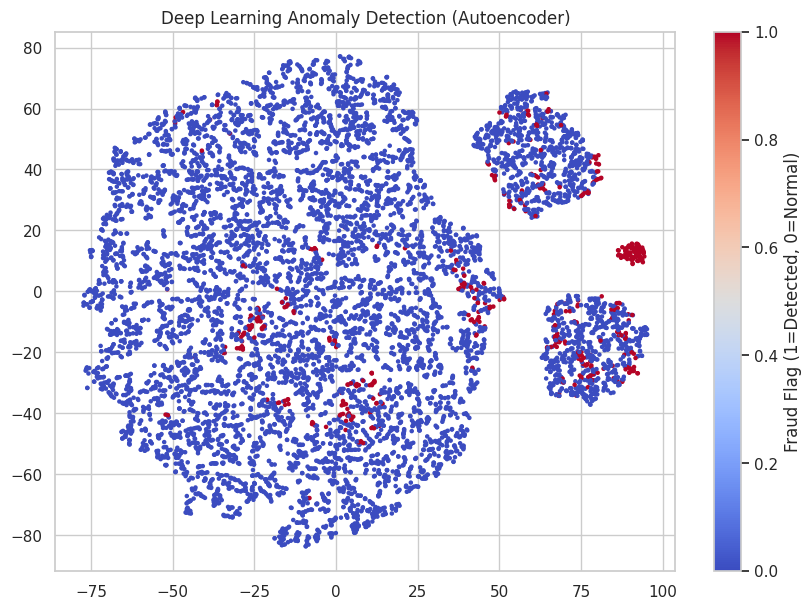

Fraud detected by DBSCAN: 1576
Fraud detected by SVM: 506
Fraud detected by Autoencoder: 500


In [35]:
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_cleaned['ae_anomaly'], cmap='coolwarm', s=5)
plt.title('Deep Learning Anomaly Detection (Autoencoder)')
plt.colorbar(label='Fraud Flag (1=Detected, 0=Normal)')
plt.show()

# Quick summary of all three models
print("Fraud detected by DBSCAN:", (db_clusters == -1).sum())
print("Fraud detected by SVM:", (oc_svm_preds == -1).sum())
print("Fraud detected by Autoencoder:", df_cleaned['ae_anomaly'].sum())

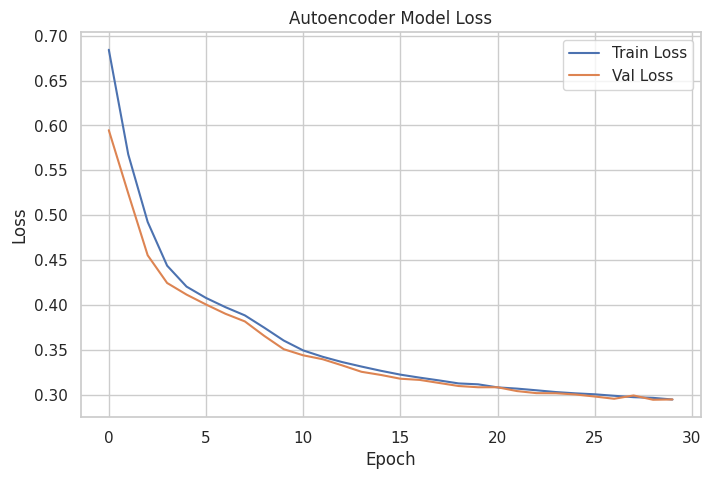

DBSCAN Results:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92      9849
           1       0.08      0.87      0.15       151

    accuracy                           0.85     10000
   macro avg       0.54      0.86      0.54     10000
weighted avg       0.98      0.85      0.91     10000


Autoencoder Results:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      9849
           1       0.12      0.39      0.18       151

    accuracy                           0.95     10000
   macro avg       0.55      0.67      0.58     10000
weighted avg       0.98      0.95      0.96     10000



In [27]:
# --- EVALUATION AND VISUALIZATION ---

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

from sklearn.metrics import classification_report

print("DBSCAN Results:")
# Treat noise (-1) as detected fraud
dbscan_labels = [1 if x == -1 else 0 for x in db_clusters]
print(classification_report(df_cleaned['is_fraud'], dbscan_labels))

print("\nAutoencoder Results:")
print(classification_report(df_cleaned['is_fraud'], df_cleaned['ae_anomaly']))

In [38]:
from sklearn.metrics import roc_auc_score

ocsvm_scores = oc_svm.decision_function(X_pca)
roc_svm = roc_auc_score(df_cleaned['is_fraud'], -ocsvm_scores)

roc_ae = roc_auc_score(df_cleaned['is_fraud'], df_cleaned['ae_loss'])

dbscan_binary = [1 if x == -1 else 0 for x in db_clusters]
roc_dbscan = roc_auc_score(df_cleaned['is_fraud'], dbscan_binary)

print(f"ROC-AUC - DBSCAN:        {roc_dbscan:.3f}")
print(f"ROC-AUC - One-Class SVM: {roc_svm:.3f}")
print(f"ROC-AUC - Autoencoder:   {roc_ae:.3f}")

ROC-AUC - DBSCAN:        0.860
ROC-AUC - One-Class SVM: 0.922
ROC-AUC - Autoencoder:   0.795


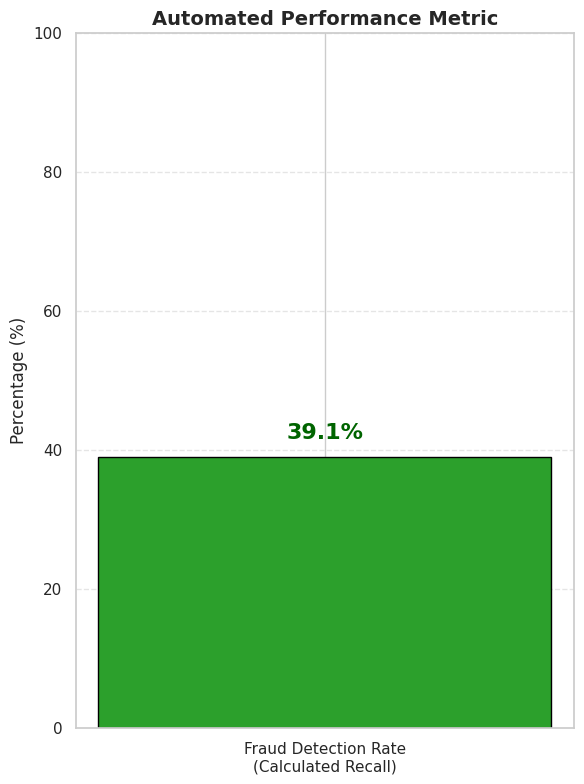

The system calculated a Fraud Detection Rate of: 39.07%


In [28]:
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt

recall_val = recall_score(df_cleaned['is_fraud'], df_cleaned['ae_anomaly'])

fraud_detection_rate = recall_val * 100

plt.figure(figsize=(6, 8))
bar = plt.bar(['Fraud Detection Rate\n(Calculated Recall)'], [fraud_detection_rate],
             color='#2ca02c', edgecolor='black', width=0.5)

plt.ylim(0, 100)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Automated Performance Metric', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.text(0, fraud_detection_rate + 2, f'{fraud_detection_rate:.1f}%',
         ha='center', va='bottom', fontsize=16, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

print(f"The system calculated a Fraud Detection Rate of: {fraud_detection_rate:.2f}%")

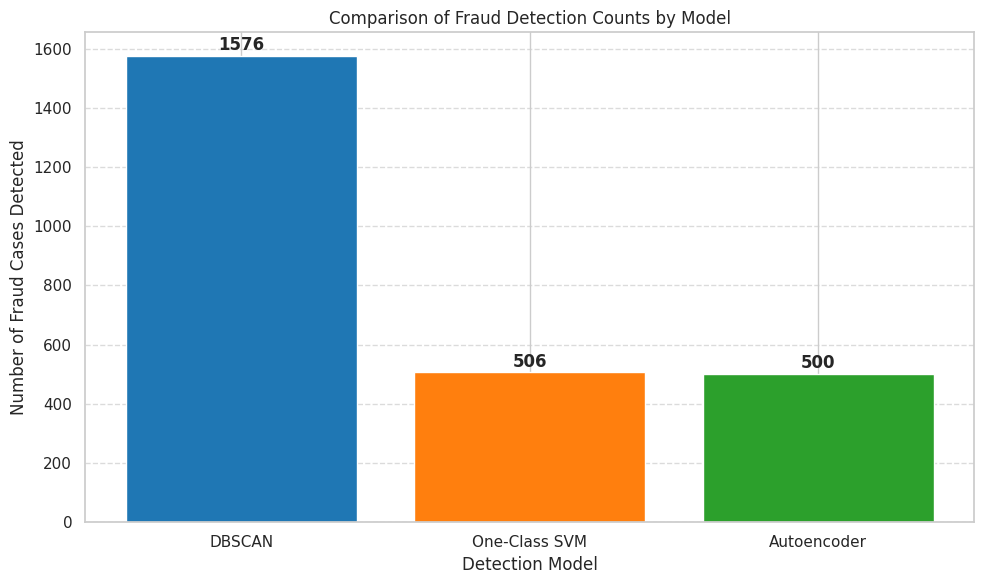

In [29]:
import matplotlib.pyplot as plt

# Data
models = ['DBSCAN', 'One-Class SVM', 'Autoencoder']
counts = [1576, 506, 500]

data = sorted(zip(models, counts), key=lambda x: x[1], reverse=True)
sorted_models, sorted_counts = zip(*data)

plt.figure(figsize=(10, 6))
plt.bar(sorted_models, sorted_counts, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Detection Model')
plt.ylabel('Number of Fraud Cases Detected')
plt.title('Comparison of Fraud Detection Counts by Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, count in enumerate(sorted_counts):
    plt.text(i, count + 20, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fraud_detection_comparison.png')

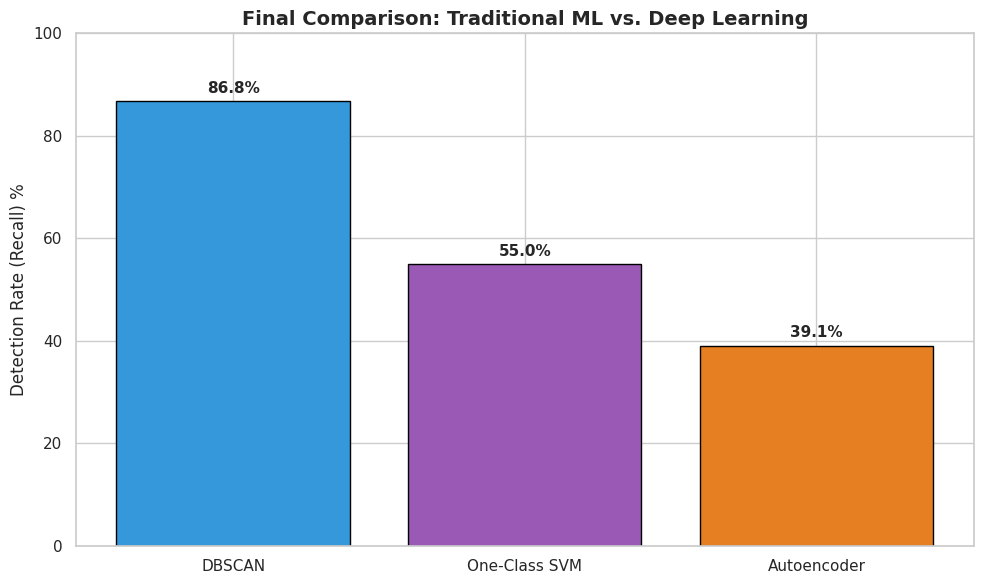

Comparison Summary:
- Highest Detection Rate: DBSCAN
- Lowest Detection Rate: Autoencoder


In [30]:
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt

dbscan_recall = recall_score(df_cleaned['is_fraud'], [1 if x == -1 else 0 for x in db_clusters])
svm_recall = recall_score(df_cleaned['is_fraud'], [1 if x == -1 else 0 for x in oc_svm_preds])
ae_recall = recall_score(df_cleaned['is_fraud'], df_cleaned['ae_anomaly'])

final_results = {
    'DBSCAN': dbscan_recall * 100,
    'One-Class SVM': svm_recall * 100,
    'Autoencoder': ae_recall * 100
}

# Plotting the Comparison
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#9b59b6', '#e67e22']
bars = plt.bar(final_results.keys(), final_results.values(), color=colors, edgecolor='black')

plt.ylim(0, 100)
plt.ylabel('Detection Rate (Recall) %', fontsize=12)
plt.title('Final Comparison: Traditional ML vs. Deep Learning', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Comparison Summary:")
print(f"- Highest Detection Rate: {max(final_results, key=final_results.get)}")
print(f"- Lowest Detection Rate: {min(final_results, key=final_results.get)}")